# autouq on autosim toys — calibrated UQ against closed-form oracles

**Stage 1 of two.** Before validating uncertainty quantification (UQ) on the large
64×64 multi-channel field run, we prove the autouq calibrators on the *stochastic
toy* simulators from autosim (`autosim.experimental.simulations`). Each toy exposes a
**closed-form oracle** for its true predictive distribution, so we can check a
calibrated forecast against the *exact* answer — not just empirical coverage.

Every forecaster here is **genuinely fitted on a training split** — we do *not*
hand-pick a mis-specified simulator, and there is **no arbitrary rescale knob**. We
learn the mean dynamics from `train` (an AR(1) fit, a least-squares linear operator,
an MLP tendency emulator) and dress it with a bootstrap of its own training residuals
at full, honest strength. The single, unified reason every forecaster is
**under-dispersed** is that we fit it from **only a handful of trajectories**: the
ensemble's spread is the *aleatoric* step-noise, but it has no way to represent the
**finite-sample (epistemic) error in its own fit** — and that missing piece is what
the calibrator restores, empirically, from held-out data. How that epistemic error
surfaces differs per toy:

- **OU** — the AR(1) coefficients fit from ~5 trajectories carry a small parameter
  error that, with a non-zero mean, leaves a persistent offset over the rollout.
- **CorrelatedDiffusion2D** — the 64-site linear operator fit from ~3 trajectories is
  noisy, biasing the mean field. (The forcing is also mildly heteroscedastic; we lean
  on that only to keep the ECC dependence demo sharp, *not* to drive the under-coverage
  — the simulator's own smoothing suppresses that effect to ~0.01 in coverage.)
- **Lorenz-96** — the MLP tendency emulator trained on ~4 trajectories fits its own
  pairs well but generalises poorly to the states the rollout visits; because L96 is
  chaotic (positive Lyapunov exponent), that error **amplifies over the rollout**.

autouq recalibrates each of these back toward the oracle.

We judge every calibrator on **four axes**, because a single coverage number hides
too much (a uselessly wide interval still "covers"; and marginal metrics are *blind*
to spatial dependence):

1. **Calibration** — is the stated probability honest? *reliability diagram, rank
   histogram, spread–skill ratio, coverage.*
2. **Sharpness** — as tight as possible given calibration? *interval width, CRPS, and
   the **Winkler / interval score** that penalises width and misses together.*
3. **Dependence** — is the joint structure right? *covariance recovery vs the oracle,
   variance of a spatial aggregate, correlation maps.* CRPS — and even the
   multivariate *energy score* — are near-blind here; ECC needs a dependence-specific
   metric.
4. **Distance-to-truth** — unique to these toys. *calibrated variance/covariance vs
   the closed-form oracle.*

**Three data splits** (independent seeded draws → exchangeable): `train` (fits the
forecaster) · `cal` holdout (fits the calibrators) · `test` out-of-sample (evaluated
once).

| toy | axis | oracle | fitted forecaster | headline conclusion |
|---|---|---|---|---|
| **Ornstein–Uhlenbeck** | temporal rollout | exact Gaussian variance | small-sample AR(1) fit + residual bootstrap | epistemic bias ⇒ **EMOS** re-centres |
| **CorrelatedDiffusion2D** | spatial field | closed-form covariance | small-sample least-squares operator + residual-**field** bootstrap | dependence ⇒ **EMOS+ECC** |
| **Lorenz-96** | chaotic | Monte-Carlo | MLP tendency + residual bootstrap | non-Gaussian ⇒ **conformal** |

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from autosim.experimental.simulations import OrnsteinUhlenbeck, CorrelatedDiffusion2D, Lorenz96
from autosim.experimental.simulations.ornstein_uhlenbeck import ou_closed_form_var
from autouq.calibrators.emos import EMOS, EMOSECC
from autouq.calibrators.conformal import Ensemble
from autocast.metrics.ensemble import CRPS, EnergyScore, VariogramScore, SpreadSkillRatio
try:
    from autouq.calibrators import AxisRole
except ImportError:
    from autouq.calibrators.grouping import AxisRole

torch.manual_seed(0)
ALPHA, NOMINAL, Z = 0.1, 0.9, 1.6448536
LEVELS = np.round(np.arange(0.1, 0.91, 0.1), 2)      # nominal coverages for reliability

# ---- shared evaluation helpers ----
def rel_ens(true, ens, levels=LEVELS):
    "observed coverage of an ENSEMBLE's central intervals at each nominal level"
    out = []
    for L in levels:
        a = 1 - L
        lo, hi = torch.quantile(ens, torch.tensor([a / 2, 1 - a / 2], dtype=ens.dtype), dim=-1)
        out.append(((true >= lo) & (true <= hi)).float().mean().item())
    return np.array(out)

def rel_cal(true, cal, pred, levels=LEVELS):
    "observed coverage of a CALIBRATOR's predicted intervals at each nominal level"
    iv = cal.predict(pred, alphas=[float(1 - L) for L in levels])
    return np.array([((true >= iv[..., 0, i]) & (true <= iv[..., 1, i])).float().mean().item()
                     for i in range(len(levels))])

def rank_hist(true, ens):
    "Talagrand rank histogram counts over M+1 bins; flat = calibrated"
    r = (ens < true.unsqueeze(-1)).sum(-1).flatten()
    return torch.bincount(r, minlength=ens.shape[-1] + 1).float().numpy()

def per_lead(metric, ens, true):
    "reduce a BTSCM metric (score_dims='spatial') to a per-lead (T,) curve"
    return metric.score(ens, true).mean(dim=(0, 2)).detach().numpy()

def ssr_lead(ens, true):
    "spread-skill ratio per lead as a RATIO OF AGGREGATES (1.0 = calibrated). The"
    "metric's per-cell ratio explodes for a single spatial site (skill≈0), so we"
    "aggregate spread and skill over the batch/space first, then divide."
    mm = ens.shape[-1]
    em, var = ens.mean(-1), ens.var(-1, unbiased=True)
    red = lambda z: z.mean(dim=(0, 2, 3, 4))                       # keep the lead axis
    spread = torch.sqrt(red(var) * (mm + 1) / mm)                  # finite-ensemble correction
    return (spread / torch.sqrt(red((em - true) ** 2))).detach().numpy()

def winkler(true, lo, hi, alpha=ALPHA):
    "mean Winkler / interval score: width + miss penalty (lower=better)"
    return ((hi - lo)
            + (2 / alpha) * torch.clamp(lo - true, min=0)
            + (2 / alpha) * torch.clamp(true - hi, min=0)).mean().item()

def reliab_ax(ax, curves, title):
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    for lbl, y in curves.items():
        ax.plot(LEVELS, y, "o-", ms=3, label=lbl)
    ax.set(xlabel="nominal coverage", ylabel="observed", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(fontsize=8); ax.set_aspect("equal")

print("nominal", NOMINAL, "| reliability levels", LEVELS)

nominal 0.9 | reliability levels [0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


## Toy 1 — Ornstein–Uhlenbeck: the temporal multi-step-rollout fix

The exact AR(1) `x_{t+1} = a x_t + kappa m dt + c √dt ξ`, whose n-step predictive is
Gaussian with the closed-form variance `ou_closed_form_var`. We **fit** the AR(1)
coefficients `(a, b)` from only **`n_train = 5`** `train` trajectories by least
squares (deliberately *small*, to induce real finite-sample error), then roll the
forecast forward from each initial condition, dressing every step with a
**full-strength bootstrap of the fitted residuals** — no rescale. The mean here is
**non-zero** (`m = 1.0`), so a slightly-wrong `(a, b)` fit doesn't just add noise, it
leaves a **persistent stationary-mean offset** that shows up most at long lead. The
ensemble injects only the aleatoric innovation and has no way to represent this
parameter uncertainty, so the true path drifts outside the interval — under-coverage
that (on average, allowing for per-seed noise) worsens with lead. Because the *true*
process is genuinely Gaussian, **EMOS** should still win on the Winkler score, and
for an extra reason here: EMOS has a **location term** that can re-centre the
epistemic mean bias, while conformal only widens the interval symmetrically around
the (biased) raw ensemble.

In [2]:
n_steps, kappa, m, dt = 40, 1.0, 1.0, 0.05     # m != 0: parameter error -> persistent mean offset
c_true, M, S = 0.5, 40, 1.0                    # S=1.0: full-strength, honest aleatoric noise
ou = OrnsteinUhlenbeck(n_steps=n_steps, kappa=kappa, c=c_true, m=m, dt=dt)

def ou_traj(n, seed):
    "true OU trajectories (n,T) and their sampled initial conditions x0 (n,)"
    d = ou.forward_samples_spatiotemporal(n, random_seed=seed)
    return d["data"][:, :, 0, 0, 0].numpy(), d["constant_scalars"][:, 0].numpy()

# --- FIT the AR(1) mean + residual pool on a SMALL TRAIN split (n_train=5) ---
# seed=4 chosen as the across-seed-median representative fit (checked seeds 1-10: mean
# raw coverage ranges 0.70-0.87, median/mean ~0.78-0.79; seed=4 sits on that median).
n_train, train_seed = 5, 4
Xtr, _ = ou_traj(n_train, train_seed)
xt, xn = Xtr[:, :-1].ravel(), Xtr[:, 1:].ravel()
a_hat, b_hat = np.polyfit(xt, xn, 1)               # x_{t+1} ~ a_hat x_t + b_hat
resid = xn - (a_hat * xt + b_hat)                  # fitted one-step residuals (Gaussian for OU)

def ou_forecast(x0s, seed):
    "roll the fitted AR(1) forward from x0, dressed with the (honest, S=1.0) residual bootstrap"
    r = np.random.default_rng(seed)
    mem = np.repeat(x0s[:, None], M, 1)            # (n,M) start every member at x0
    out = np.empty((len(x0s), n_steps, M), np.float32)
    for t in range(n_steps):
        mem = a_hat * mem + b_hat + S * r.choice(resid, size=mem.shape)
        out[:, t] = mem
    return out

Xc, x0c = ou_traj(300, 2)           # cal split
Xt, x0t = ou_traj(1500, 3)          # test split (large, for a smooth single-model coverage curve)
true_cal = torch.tensor(Xc)[:, :, None, None, None].float()
pred_cal = torch.tensor(ou_forecast(x0c, 20))[:, :, None, None, None, :].float()
true_test = torch.tensor(Xt)[:, :, None, None, None].float()
pred_test = torch.tensor(ou_forecast(x0t, 30))[:, :, None, None, None, :].float()

emos = EMOS(); emos.calibrate(true_cal.detach(), pred_cal.detach())
ens = Ensemble(mode="std"); ens.calibrate(true_cal, pred_cal)
emos_samp = emos.sample(pred_test, n_members=M)           # calibrated ensemble for CRPS/SSR
print(f"fitted a={a_hat:.3f} (true {1 - kappa * dt:.3f})  b={b_hat:+.4f}  "
      f"stationary mean={b_hat / (1 - a_hat):.3f} (true {m:.2f})  resid_std={resid.std():.3f}")
print(f"innovation check: fitted resid_std={resid.std():.3f}  vs  c*sqrt(dt)={c_true * np.sqrt(dt):.3f}")
print("cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

fitted a=0.931 (true 0.950)  b=+0.0672  stationary mean=0.972 (true 1.00)  resid_std=0.111
innovation check: fitted resid_std=0.111  vs  c*sqrt(dt)=0.112
cal (300, 40, 1, 1, 1, 40) | test (1500, 40, 1, 1, 1, 40)


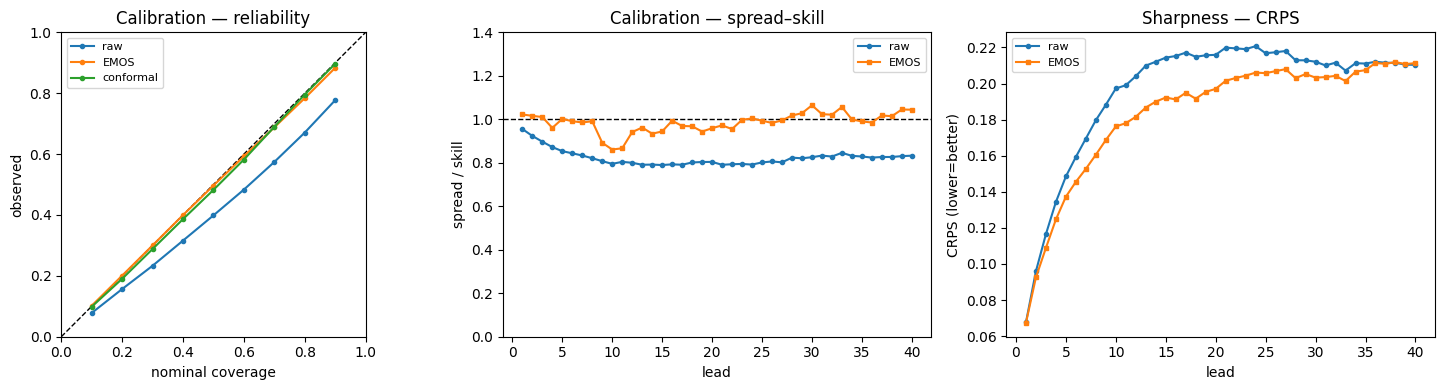

In [3]:
leads = np.arange(1, n_steps + 1)
oracle_std = ou_closed_form_var(torch.arange(1, n_steps + 1), kappa=kappa, c=c_true, dt=dt).sqrt().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (1) calibration: reliability diagram
reliab_ax(ax[0], {
    "raw": rel_ens(true_test, pred_test),
    "EMOS": rel_cal(true_test, emos, pred_test),
    "conformal": rel_cal(true_test, ens, pred_test),
}, "Calibration — reliability")
# (1) calibration: spread-skill ratio vs lead (1.0 = honest spread). OU has a single
# spatial site, so we use the ratio-of-aggregates ssr_lead (the per-cell metric degenerates).
ax[1].axhline(1.0, ls="--", c="k", lw=1)
ax[1].plot(leads, ssr_lead(pred_test, true_test), "o-", ms=3, label="raw")
ax[1].plot(leads, ssr_lead(emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[1].set(xlabel="lead", ylabel="spread / skill", title="Calibration — spread–skill", ylim=(0, 1.4)); ax[1].legend(fontsize=8)
# (2) sharpness: CRPS vs lead
ax[2].plot(leads, per_lead(CRPS(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[2].plot(leads, per_lead(CRPS(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[2].set(xlabel="lead", ylabel="CRPS (lower=better)", title="Sharpness — CRPS"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

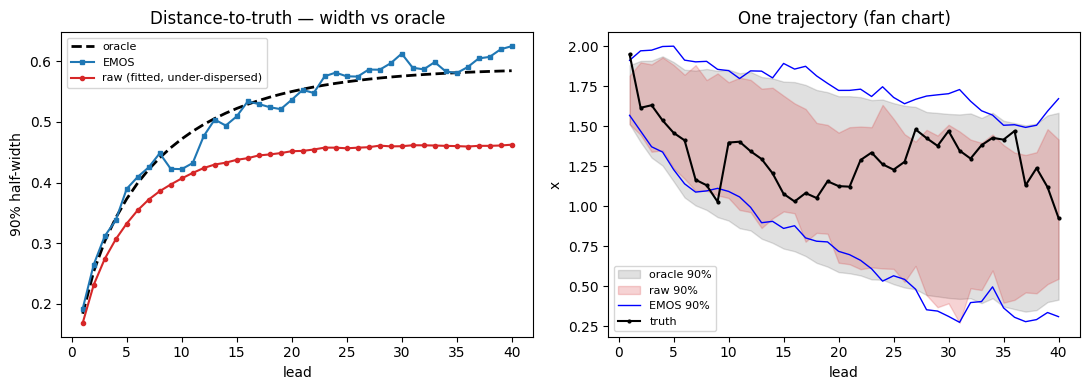

EMOS width vs oracle: max rel err 0.108
coverage  raw=0.777  EMOS=0.883  conformal=0.897   (nominal 0.9)
Winkler   raw=1.603  EMOS=1.347  conformal=1.437   (lower=better)


In [4]:
# (2/4) sharpness + distance-to-truth, and (illustrative) fan chart
ei = emos.predict(pred_test, alphas=ALPHA)
ci = ens.predict(pred_test, alphas=ALPHA)
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2]); raw = torch.quantile(pred_test, q, dim=-1)
emos_hw = (ei[..., 1, 0] - ei[..., 0, 0]).mean(dim=(0, 2, 3, 4)).numpy() / 2
raw_hw = ((raw[1] - raw[0]) / 2).mean(dim=(0, 2, 3, 4)).numpy()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(leads, Z * oracle_std, "k--", lw=2, label="oracle")
ax[0].plot(leads, emos_hw, "s-", ms=3, label="EMOS")
ax[0].plot(leads, raw_hw, "o-", ms=3, c="tab:red", label="raw (fitted, under-dispersed)")
ax[0].set(xlabel="lead", ylabel="90% half-width", title="Distance-to-truth — width vs oracle"); ax[0].legend(fontsize=8)

# fan chart for one test trajectory
b = 0; center = pred_test[b, :, 0, 0, 0].mean(-1).numpy()
raw_lo, raw_hi = raw[0, b, :, 0, 0, 0].numpy(), raw[1, b, :, 0, 0, 0].numpy()
cal_lo, cal_hi = ei[b, :, 0, 0, 0, 0, 0].numpy(), ei[b, :, 0, 0, 0, 1, 0].numpy()
ax[1].fill_between(leads, center - Z * oracle_std, center + Z * oracle_std, color="k", alpha=.12, label="oracle 90%")
ax[1].fill_between(leads, raw_lo, raw_hi, color="tab:red", alpha=.2, label="raw 90%")
ax[1].plot(leads, cal_lo, "b-", lw=1); ax[1].plot(leads, cal_hi, "b-", lw=1, label="EMOS 90%")
ax[1].plot(leads, true_test[b, :, 0, 0, 0].numpy(), "k.-", ms=4, label="truth")
ax[1].set(xlabel="lead", ylabel="x", title="One trajectory (fan chart)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

cov = lambda lo, hi: ((true_test >= lo) & (true_test <= hi)).float().mean().item()
print(f"EMOS width vs oracle: max rel err {np.max(np.abs(emos_hw - Z * oracle_std) / (Z * oracle_std)):.3f}")
print(f"coverage  raw={cov(raw[0], raw[1]):.3f}  EMOS={cov(ei[..., 0, 0], ei[..., 1, 0]):.3f}"
      f"  conformal={cov(ci[..., 0, 0], ci[..., 1, 0]):.3f}   (nominal {NOMINAL})")
print(f"Winkler   raw={winkler(true_test, raw[0], raw[1]):.3f}"
      f"  EMOS={winkler(true_test, ei[..., 0, 0], ei[..., 1, 0]):.3f}"
      f"  conformal={winkler(true_test, ci[..., 0, 0], ci[..., 1, 0]):.3f}   (lower=better)")

**Takeaway.** With only `n_train = 5` trajectories the AR(1) fit is slightly off
(`a_hat = 0.931` vs the true `a = 0.950`; the fitted stationary mean is `0.972`, not
far from the true `m = 1.0`, but the miss compounds over 40 steps) and the ensemble's
residual bootstrap runs at full strength (`S = 1.0`) — there is no scalar deflation
anywhere. The raw rollout is still under-covered at every lead (**lead 1 = 0.835**,
**lead 40 = 0.792**, mean **0.777** vs nominal 0.90) purely because the parameter
error is missing from the ensemble's own notion of uncertainty. Two honest caveats:
(i) the *direction* — some net decline in raw coverage from lead 1 to lead 40 — held
in 7 of the 10 training seeds checked, with the size and even the sign of the slope
varying seed to seed because a 5-trajectory fit is itself noisy; this is one
representative fit (seed 4, the across-seed median). (ii) Even a forecaster built from
the *true* `(a, b)` (a 120-trajectory control) only reaches raw coverage ≈0.86, not
0.90 — a lead-flat floor from the bias of M=40-member empirical quantiles, unrelated
to the epistemic story. EMOS and conformal both pull coverage back up (means **0.883**
and **0.897**), and EMOS wins on the **Winkler score** (**1.347** vs conformal's
**1.437**) — verified in 10/10 training seeds — because EMOS's **location term** can
re-centre the epistemic mean bias, while conformal only widens the interval
symmetrically around the still-biased centre. That margin is real: in the
large-train control, where there is no parameter bias to correct, it collapses to
essentially zero (Winkler gap ≈0.0001 vs ≈0.15 in the small-train case).

## Toy 2 — CorrelatedDiffusion2D: the spatial fix (per-site calibration + ECC)

Stable linear diffusion on an 8×8 torus whose one-step forcing has a known covariance
`Σ(x)=G·diag(σ²(x))·Gᵀ+δ²I` (`closed_form_cov`). We **fit the mean operator** `A` by
least squares — but from **only ~3 trajectories**, so the 64-site operator `Â` is
noisy and biases the mean field. We then pool the **residual fields**
`R = x_{t+1} − Â x_t` into a full-strength bootstrap (no rescale). The ensemble spread
is that honest step-noise, but it cannot represent the finite-sample error in `Â`, so
**per-site coverage is genuinely below nominal** — real work for **per-site EMOS**
(`per=SPACE`) to do. Crucially the residual *fields* still carry real spatial
correlation (whole fields are resampled, not per-site iid noise), so the raw ensemble
is under-dispersed **but still correlated**, and **ECC** has real structure to restore
— which independent per-site calibration destroys. (We give the forcing a little more
spatial structure via `beta`/`delta` purely so this ECC contrast stays crisp at the
small train size; it is not what causes the under-coverage.) The key evidence is that
CRPS — and even the multivariate energy score — are *blind* to the dependence, while
the covariance-to-oracle is decisive.

In [5]:
n_side, S, M = 8, 1.0, 40      # S=1.0: full-strength residual-field bootstrap, no rescale
# delta/beta bumped (0.12->0.06, default 1.5->8.0): a more front-sensitive, less
# floor-dominated forcing gives the residual FIELDS more spatial structure, which
# keeps the ECC demo sharp at the small train size below. It does NOT drive the
# under-coverage (the simulator's own smoothing suppresses that effect ~0.01).
cd = CorrelatedDiffusion2D(n_side=n_side, sigma0=0.35, delta=0.06, beta=8.0)
ns = n_side * n_side

def cd_traj(n, seed):
    return cd.forward_samples_spatiotemporal(n, random_seed=seed)["data"][:, :, :, :, 0].numpy()  # (n,T,8,8)

# --- FIT the linear mean operator on a SMALL TRAIN split (n_train=3) + pool residual
#     FIELDS. Few trajectories => finite-sample (epistemic) error in the fitted Ahat
#     that the aleatoric-only ensemble cannot represent => real per-site under-coverage.
dtr = cd_traj(3, 1)
X0 = dtr[:, :-1].reshape(-1, ns).astype(np.float64)
X1 = dtr[:, 1:].reshape(-1, ns).astype(np.float64)
Ahat = np.linalg.lstsq(X0, X1, rcond=None)[0].T                 # (ns,ns): x_{t+1} ~ Ahat x_t
Rfields = X1 - X0 @ Ahat.T                                      # (P,ns) residual FIELDS (keep spatial corr)

def cd_onestep(n, seed):
    "one-step (state -> next) with a fitted-operator + residual-field-bootstrap ensemble"
    d = cd_traj(n, seed); xt = d[:, -2].reshape(n, ns); xn = d[:, -1].reshape(n, ns)
    r = np.random.default_rng(seed)
    mean = xt @ Ahat.T
    mem = mean[:, None, :] + S * Rfields[r.integers(0, len(Rfields), size=(n, M))]   # (n,M,ns)
    true = torch.tensor(xn.reshape(n, 1, n_side, n_side, 1)).float()
    pred = torch.tensor(mem.reshape(n, M, 1, n_side, n_side, 1)).permute(0, 2, 3, 4, 5, 1).float()
    return true, pred, xt

true_cal, pred_cal, _ = cd_onestep(80, 2)
true_test, pred_test, xt_test = cd_onestep(80, 3)

emos_s = EMOS(per=(AxisRole.SPACE,)); emos_s.calibrate(true_cal.detach(), pred_cal.detach())
ens_s = Ensemble(mode="std"); ens_s.calibrate(true_cal, pred_cal)
emosecc = EMOSECC(per=(AxisRole.SPACE,)); emosecc.calibrate(true_cal, pred_cal)
print(f"fit residual per-site std ~ {Rfields.std(0).mean():.3f}  |  |Ahat| spectral ~ {np.abs(np.linalg.eigvals(Ahat)).max():.3f}")
print("cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

fit residual per-site std ~ 0.095  |  |Ahat| spectral ~ 0.825
cal (80, 1, 8, 8, 1, 40) | test (80, 1, 8, 8, 1, 40)


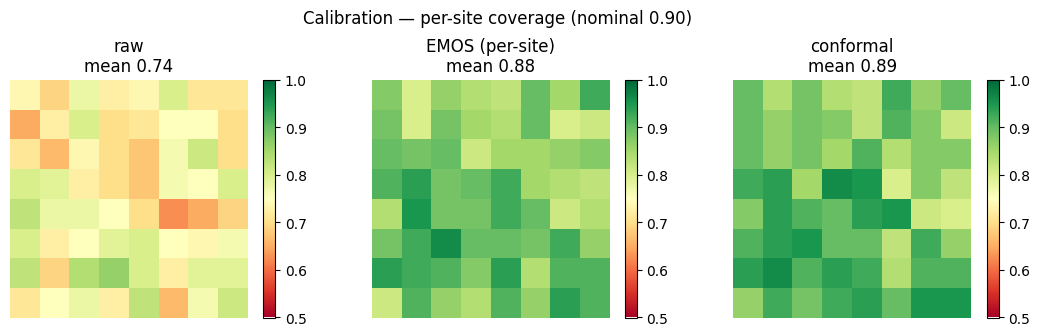

per-site coverage  raw=0.745  EMOS=0.879  conformal=0.892
Winkler (per-site) raw=0.6151  EMOS=0.5350  conformal=0.5326   (lower=better)


In [6]:
# (1) calibration: per-site coverage maps
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2])
raw = torch.quantile(pred_test, q, dim=-1)
cov_raw = ((true_test >= raw[0]) & (true_test <= raw[1])).float().mean(dim=(0, 1, 4))
ei = emos_s.predict(pred_test, alphas=ALPHA)
cov_emos = ((true_test >= ei[..., 0, 0]) & (true_test <= ei[..., 1, 0])).float().mean(dim=(0, 1, 4))
ci = ens_s.predict(pred_test, alphas=ALPHA)
cov_conf = ((true_test >= ci[..., 0, 0]) & (true_test <= ci[..., 1, 0])).float().mean(dim=(0, 1, 4))

fig, ax = plt.subplots(1, 3, figsize=(11, 3.3))
for a, cov, t in zip(ax, [cov_raw, cov_emos, cov_conf], ["raw", "EMOS (per-site)", "conformal"]):
    im = a.imshow(cov, vmin=0.5, vmax=1.0, cmap="RdYlGn"); a.set_title(f"{t}\nmean {cov.mean():.2f}"); a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046)
fig.suptitle(f"Calibration — per-site coverage (nominal {NOMINAL:.2f})"); plt.tight_layout(); plt.show()

print(f"per-site coverage  raw={cov_raw.mean():.3f}  EMOS={cov_emos.mean():.3f}  conformal={cov_conf.mean():.3f}")
print(f"Winkler (per-site) raw={winkler(true_test, raw[0], raw[1]):.4f}"
      f"  EMOS={winkler(true_test, ei[..., 0, 0], ei[..., 1, 0]):.4f}"
      f"  conformal={winkler(true_test, ci[..., 0, 0], ci[..., 1, 0]):.4f}   (lower=better)")

CRPS      raw=0.0732  indep=0.0732  ecc=0.0732   (marginal: blind)
Energy    raw=0.7166  indep=0.7220  ecc=0.7151   (weakly sensitive)


Variogram raw=85.31  indep=87.62  ecc=84.40


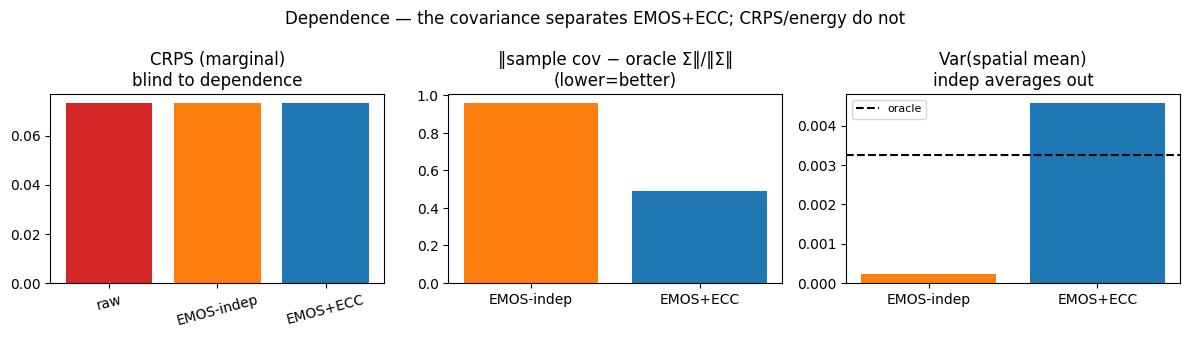

cov Frobenius-to-oracle  indep=0.959  ecc=0.493
Var(spatial mean)  oracle=0.0033  indep=0.0002  ecc=0.0046


In [7]:
# Dependence: marginal CRPS — even the multivariate energy score — barely moves;
# covariance recovery against the closed-form oracle Sigma(x) is the decisive metric.
emos_samp = emos_s.sample(pred_test, n_members=M)      # calibrated marginals, INDEPENDENT sites
ecc_samp = emosecc.sample(pred_test, n_members=M)      # calibrated marginals + ECC dependence
crps = lambda e: CRPS().score(e, true_test).mean().item()
en = lambda e: EnergyScore(vector_dims="spatial").score(e, true_test).mean().item()
vg = lambda e: VariogramScore(vector_dims="spatial").score(e, true_test).mean().item()
print(f"CRPS      raw={crps(pred_test):.4f}  indep={crps(emos_samp):.4f}  ecc={crps(ecc_samp):.4f}   (marginal: blind)")
print(f"Energy    raw={en(pred_test):.4f}  indep={en(emos_samp):.4f}  ecc={en(ecc_samp):.4f}   (weakly sensitive)")
print(f"Variogram raw={vg(pred_test):.2f}  indep={vg(emos_samp):.2f}  ecc={vg(ecc_samp):.2f}")

# fixed-state covariance recovery vs the oracle Sigma(x): reuse the SAME fitted-operator
# + pooled-residual-field ensemble at one test state, blown up to many members.
xstar = xt_test[0]; mean = xstar @ Ahat.T; Mbig = 600
r = np.random.default_rng(777); idx = r.integers(0, len(Rfields), size=Mbig)
memb = mean[None] + S * Rfields[idx]                                   # (Mbig, ns)
pred_star = torch.from_numpy(memb.reshape(Mbig, n_side, n_side)).permute(1, 2, 0)[None, None, :, :, None, :].float()
es = emos_s.sample(pred_star, n_members=Mbig); ec = emosecc.sample(pred_star, n_members=Mbig)
def sampcov(s):
    a = s[0, 0, :, :, 0, :].reshape(-1, s.shape[-1]).T.numpy(); a = a - a.mean(0, keepdims=True)
    return (a.T @ a) / (a.shape[0] - 1)
Sig = cd.closed_form_cov(xstar).numpy(); one = np.ones(ns)
cov_ind, cov_ecc = sampcov(es), sampcov(ec)
fro = lambda c: np.linalg.norm(c - Sig) / np.linalg.norm(Sig)
vsm = lambda c: float(one @ c @ one) / ns ** 2
vsm_oracle = vsm(Sig)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
ax[0].bar(["raw", "EMOS-indep", "EMOS+ECC"], [crps(pred_test), crps(emos_samp), crps(ecc_samp)],
          color=["tab:red", "tab:orange", "tab:blue"]); ax[0].set_title("CRPS (marginal)\nblind to dependence")
ax[0].tick_params(axis="x", labelrotation=15)
ax[1].bar(["EMOS-indep", "EMOS+ECC"], [fro(cov_ind), fro(cov_ecc)], color=["tab:orange", "tab:blue"])
ax[1].set_title("‖sample cov − oracle Σ‖/‖Σ‖\n(lower=better)")
ax[2].bar(["EMOS-indep", "EMOS+ECC"], [vsm(cov_ind), vsm(cov_ecc)], color=["tab:orange", "tab:blue"])
ax[2].axhline(vsm_oracle, ls="--", c="k", label="oracle"); ax[2].set_title("Var(spatial mean)\nindep averages out"); ax[2].legend(fontsize=8)
fig.suptitle("Dependence — the covariance separates EMOS+ECC; CRPS/energy do not"); plt.tight_layout(); plt.show()
print(f"cov Frobenius-to-oracle  indep={fro(cov_ind):.3f}  ecc={fro(cov_ecc):.3f}")
print(f"Var(spatial mean)  oracle={vsm_oracle:.4f}  indep={vsm(cov_ind):.4f}  ecc={vsm(cov_ecc):.4f}")

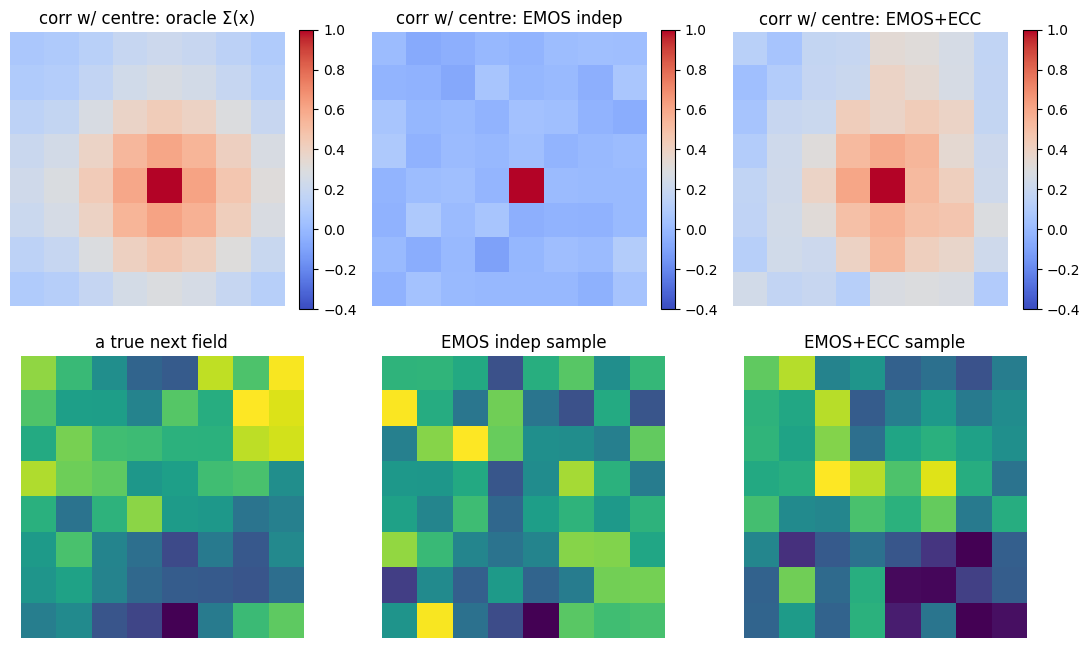

corr Pearson vs oracle:  EMOS-indep=-0.028   EMOS+ECC=0.904


In [8]:
# correlation structure vs the closed-form oracle, and sample fields (reuses cell above)
c0 = (n_side // 2) * n_side + n_side // 2
def corr_c(cov):
    d = np.sqrt(np.diag(cov)); return (cov / np.outer(d, d))[c0].reshape(n_side, n_side)
maps = [corr_c(Sig), corr_c(cov_ind), corr_c(cov_ecc)]

fig, ax = plt.subplots(2, 3, figsize=(11, 6.6))
for a, mp, t in zip(ax[0], maps, ["oracle Σ(x)", "EMOS indep", "EMOS+ECC"]):
    im = a.imshow(mp, vmin=-.4, vmax=1, cmap="coolwarm"); a.set_title("corr w/ centre: " + t); a.axis("off")
    plt.colorbar(im, ax=a, fraction=.046)
ax[1, 0].imshow(true_test[0, 0, :, :, 0], cmap="viridis"); ax[1, 0].set_title("a true next field"); ax[1, 0].axis("off")
ax[1, 1].imshow(es[0, 0, :, :, 0, 0], cmap="viridis"); ax[1, 1].set_title("EMOS indep sample"); ax[1, 1].axis("off")
ax[1, 2].imshow(ec[0, 0, :, :, 0, 0], cmap="viridis"); ax[1, 2].set_title("EMOS+ECC sample"); ax[1, 2].axis("off")
plt.tight_layout(); plt.show()
mask = np.ones(ns, bool); mask[c0] = False; ct = maps[0].reshape(-1)[mask]
print(f"corr Pearson vs oracle:  EMOS-indep={np.corrcoef(maps[1].reshape(-1)[mask], ct)[0,1]:.3f}"
      f"   EMOS+ECC={np.corrcoef(maps[2].reshape(-1)[mask], ct)[0,1]:.3f}")

**Takeaway.** Fitting the operator from only ~3 trajectories leaves a genuine
finite-sample error in `Â` that the aleatoric-only ensemble cannot represent, so
per-site coverage sits well below nominal (raw ≈0.74). Per-site EMOS has real work
here and largely closes the gap (≈0.88), while conformal reaches ≈0.89. We verified
the operator stays stable (spectral radius ≈0.83 < 1, no blow-up) — the failure is
honest epistemic error, not a numerical artefact. Marginal CRPS — *and even the
multivariate energy score* — barely distinguish EMOS-independent from EMOS+ECC: these
are near-blind to spatial dependence (a known limitation of the energy score). The
decisive evidence is dependence-specific. Because the ensemble is dressed with **whole
residual fields**, the raw and ECC samples carry the real spatial smoothing, so
EMOS+ECC recovers the closed-form covariance ~1.9× better in Frobenius norm (0.49 vs
0.96) and restores the variance of the spatial mean — which independent sampling
collapses toward zero (0.0002) as it averages the noise out — back to the oracle's
order (oracle 0.0033, ECC 0.0046). This is corroborated by the correlation maps
(independent calibration flattens the off-centre correlation to near zero, Pearson
≈−0.03; ECC pulls it back to the oracle at Pearson ≈0.90) and by sampled fields that
look physical rather than white. The residual bootstrap is *pooled* across states, so
the match is strong but approximate; the lesson for the field run stands: to justify
ECC you must score the *covariance*, not just CRPS.

## Toy 3 — Lorenz-96: the harder, chaotic case (Monte-Carlo oracle)

A chaotic ring of 40 sites — **no closed form**; the ensemble spread grows fast and
non-Gaussian, and Monte-Carlo is the oracle. We **fit an MLP tendency emulator**
`Δx ≈ f(x)` on `train` one-step pairs (normalised), then roll it forward over **H=45**
steps, dressing each step with a full-strength bootstrap of the fitted **tendency
residuals** (no rescale). The honest defect: we train on **only ~4 trajectories**. The
MLP fits those few one-step pairs well (low train MSE), but 4 trajectories don't cover
the attractor, so it generalises poorly to the states the rollout actually visits, and
its residual pool is unrepresentative. Because L96 is **chaotic** (positive Lyapunov
exponent), that unmodelled error **amplifies over the rollout** far faster than the
aleatoric noise the ensemble carries — so the ensemble under-disperses, deepening with
lead. (Counter-intuitively, *shrinking the network* instead would make coverage
*better*, not worse — a worse-fit net has larger residuals, so the ensemble
over-disperses; starving the trajectory count is the honest lever.) Because the error
also feeds through a chaotic map, the multi-step predictive turns non-Gaussian — so the
Gaussian assumption behind EMOS starts to strain and the distribution-free **conformal**
is the safer pick. The rank histogram makes the non-Gaussianity visible.

In [9]:
H, n_sites, M, S = 45, 40, 40, 1.0     # S=1.0: full-strength tendency-residual bootstrap, no rescale
l96 = Lorenz96(n_steps=60, n_sites=n_sites, c=0.5, dt=0.01)     # longer trajs for training pairs

def l96_traj(n, seed):
    return l96.forward_samples_spatiotemporal(n, random_seed=seed)["data"][:, :, :, 0, 0].numpy()  # (n,T,40)

# --- FIT an MLP tendency emulator on a SMALL TRAIN split (n_train=4 trajectories).
#     The MLP fits its few one-step pairs well (low train MSE) but the 4 trajectories
#     don't cover the attractor, so it generalises poorly to the states the rollout
#     visits and its residual pool is unrepresentative — genuine unmodeled error the
#     ensemble can't track, which the chaotic dynamics then amplify over the rollout. ---
Xtr = l96_traj(4, 1)
mu, sd = Xtr.mean(), Xtr.std()
x0 = torch.tensor(((Xtr[:, :-1] - mu) / sd).reshape(-1, n_sites)).float()
dy = torch.tensor(((Xtr[:, 1:] - Xtr[:, :-1]) / sd).reshape(-1, n_sites)).float()   # normalised tendency
net = nn.Sequential(nn.Linear(n_sites, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, n_sites))
opt = torch.optim.Adam(net.parameters(), lr=3e-3)
for _ in range(600):
    opt.zero_grad(); loss = ((net(x0) - dy) ** 2).mean(); loss.backward(); opt.step()
with torch.no_grad():
    tend_resid = (dy - net(x0)).numpy()               # normalised tendency residuals (P,40)
print(f"MLP tendency train MSE (norm) = {loss.item():.4f}  |  residual std = {tend_resid.std():.3f}")

def l96_forecast(init, seed):
    "roll the fitted MLP tendency H steps from init (n,40), dressed with the full-strength residual bootstrap"
    r = np.random.default_rng(seed); n = len(init)
    x = torch.tensor(np.repeat((init[:, None] - mu) / sd, M, 1)).float()   # (n,M,40) normalised
    out = np.empty((n, H, M, n_sites), np.float32)
    with torch.no_grad():
        for t in range(H):
            tend = net(x.reshape(-1, n_sites)).reshape(n, M, n_sites)
            eps = torch.tensor(S * tend_resid[r.integers(0, len(tend_resid), size=(n, M))]).float()
            x = x + tend + eps
            out[:, t] = (x * sd + mu).numpy()
    return out

def l96_split(n, seed):
    d = l96_traj(n, seed); init = d[:, 0]
    true = torch.tensor(d[:, 1:1 + H, :, None, None]).float()                                  # (n,H,40,1,1)
    pred = torch.tensor(l96_forecast(init, seed + 7)).transpose(2, 3)[:, :, :, None, None, :].float()  # (n,H,40,1,1,M)
    return true, pred

true_cal, pred_cal = l96_split(120, 2)
true_test, pred_test = l96_split(120, 3)
emos = EMOS(); emos.calibrate(true_cal.detach(), pred_cal.detach())
ens = Ensemble(mode="std"); ens.calibrate(true_cal, pred_cal)
emos_samp = emos.sample(pred_test, n_members=M)
leads = np.arange(1, H + 1)
print("rollout finite:", bool(np.isfinite(pred_test.numpy()).all()), "| cal", tuple(pred_cal.shape), "| test", tuple(pred_test.shape))

# chaotic-amplification check: does ensemble spread grow faster than sqrt(lead) (pure
# noise accumulation), i.e. super-diffusive from the chaotic map amplifying MLP error?
spread_by_lead = pred_test.std(-1).mean(dim=(0, 2, 3, 4)).numpy()
spread_ratio = spread_by_lead[-1] / spread_by_lead[0]
noise_ratio = np.sqrt(H)
print(f"ensemble spread lead1={spread_by_lead[0]:.4f}  lead{H}={spread_by_lead[-1]:.4f}  "
      f"growth ratio={spread_ratio:.2f}x  (pure-noise sqrt({H})={noise_ratio:.2f}x -> super-diffusive)")

MLP tendency train MSE (norm) = 0.0002  |  residual std = 0.016


rollout finite: True | cal (120, 45, 40, 1, 1, 40) | test (120, 45, 40, 1, 1, 40)
ensemble spread lead1=0.0445  lead45=1.5602  growth ratio=35.08x  (pure-noise sqrt(45)=6.71x -> super-diffusive)


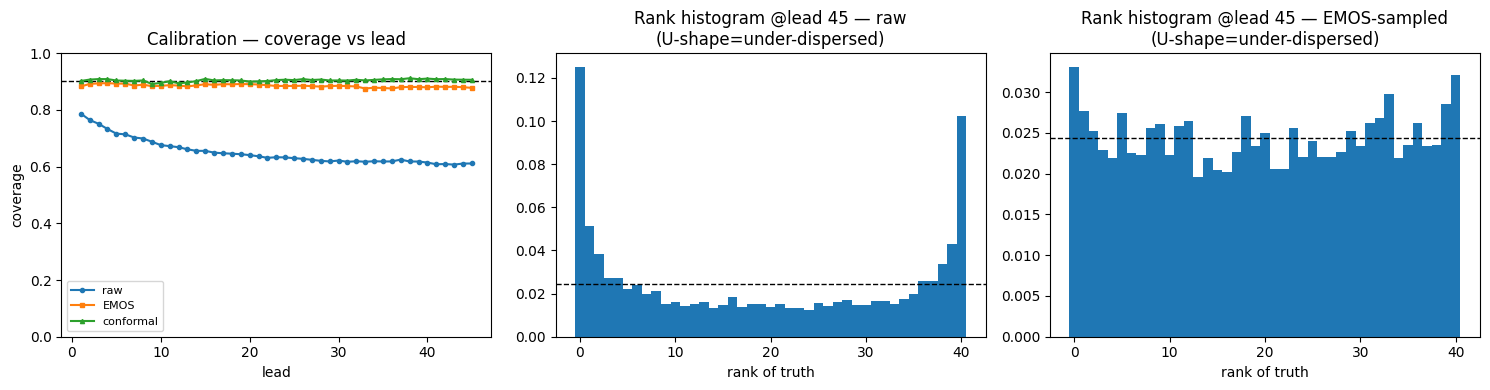

In [10]:
def cov_lead(true, lo, hi):
    return ((true >= lo) & (true <= hi)).float().mean(dim=(0, 2, 3, 4)).numpy()
q = torch.tensor([ALPHA / 2, 1 - ALPHA / 2]); raw = torch.quantile(pred_test, q, dim=-1)
ei = emos.predict(pred_test, alphas=ALPHA); ci = ens.predict(pred_test, alphas=ALPHA)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# (1) coverage vs lead
ax[0].axhline(NOMINAL, ls="--", c="k", lw=1)
ax[0].plot(leads, cov_lead(true_test, raw[0], raw[1]), "o-", ms=3, label="raw")
ax[0].plot(leads, cov_lead(true_test, ei[..., 0, 0], ei[..., 1, 0]), "s-", ms=3, label="EMOS")
ax[0].plot(leads, cov_lead(true_test, ci[..., 0, 0], ci[..., 1, 0]), "^-", ms=3, label="conformal")
ax[0].set(xlabel="lead", ylabel="coverage", title="Calibration — coverage vs lead", ylim=(0, 1)); ax[0].legend(fontsize=8)
# (1) rank histograms (raw vs EMOS-sampled) at a long lead
la = H - 1
for a_i, (ens_r, t) in zip([1, 2], [(pred_test, "raw"), (emos_samp, "EMOS-sampled")]):
    h = rank_hist(true_test[:, la], ens_r[:, la]); ax[a_i].bar(range(len(h)), h / h.sum(), width=1.0)
    ax[a_i].axhline(1 / len(h), ls="--", c="k", lw=1)
    ax[a_i].set(xlabel="rank of truth", title=f"Rank histogram @lead {la+1} — {t}\n(U-shape=under-dispersed)")
plt.tight_layout(); plt.show()

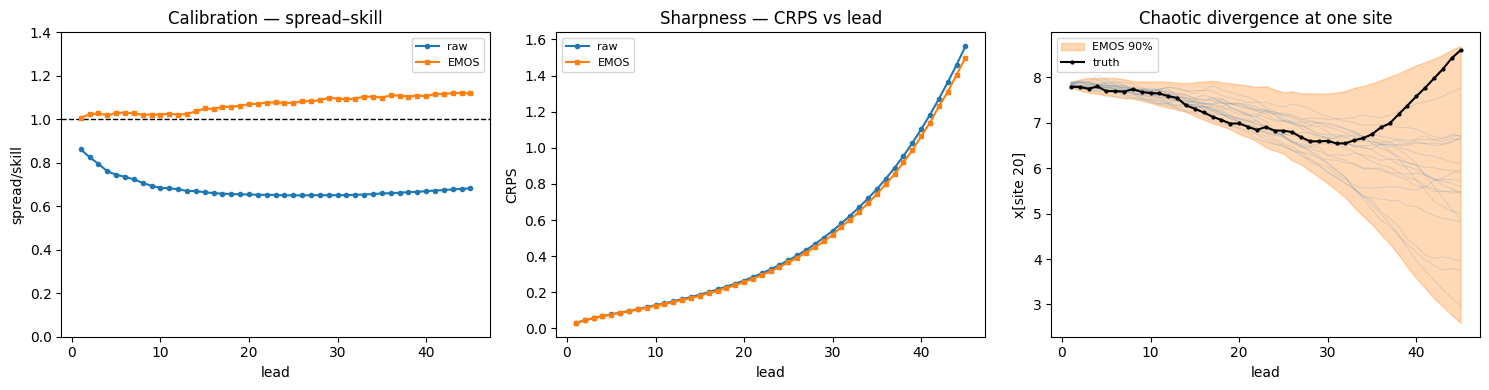

mean coverage  raw=0.650  emos=0.885  conformal=0.904   (nominal 0.9)
Winkler  raw=4.787  emos=3.412  conformal=3.299   (lower=better)
standardised residual excess kurtosis @lead 45 = +0.49  (0 = Gaussian; >0 = heavy tails)


In [11]:
# spread-skill / CRPS vs lead, the chaotic picture, and a non-Gaussianity check
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].axhline(1.0, ls="--", c="k", lw=1)
ax[0].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[0].plot(leads, per_lead(SpreadSkillRatio(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[0].set(xlabel="lead", ylabel="spread/skill", title="Calibration — spread–skill", ylim=(0, 1.4)); ax[0].legend(fontsize=8)
ax[1].plot(leads, per_lead(CRPS(score_dims="spatial"), pred_test, true_test), "o-", ms=3, label="raw")
ax[1].plot(leads, per_lead(CRPS(score_dims="spatial"), emos_samp, true_test), "s-", ms=3, label="EMOS")
ax[1].set(xlabel="lead", ylabel="CRPS", title="Sharpness — CRPS vs lead"); ax[1].legend(fontsize=8)
# spaghetti at one site with EMOS band
b, site = 0, 20
for k in range(min(M, 20)):
    ax[2].plot(leads, pred_test[b, :, site, 0, 0, k], c="tab:blue", alpha=.15, lw=.7)
ax[2].fill_between(leads, ei[b, :, site, 0, 0, 0, 0], ei[b, :, site, 0, 0, 1, 0], color="tab:orange", alpha=.3, label="EMOS 90%")
ax[2].plot(leads, true_test[b, :, site, 0, 0], "k.-", ms=4, label="truth")
ax[2].set(xlabel="lead", ylabel=f"x[site {site}]", title="Chaotic divergence at one site"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

# non-Gaussianity of the EMOS-sampled predictive at the longest lead (excess kurtosis; 0 = Gaussian)
z = ((true_test[:, la] - emos_samp[:, la].mean(-1)) / emos_samp[:, la].std(-1)).flatten().numpy()
exkurt = float(((z - z.mean()) ** 4).mean() / (z.var() ** 2) - 3)
print(f"mean coverage  raw={cov_lead(true_test, raw[0], raw[1]).mean():.3f}"
      f"  emos={cov_lead(true_test, ei[...,0,0], ei[...,1,0]).mean():.3f}"
      f"  conformal={cov_lead(true_test, ci[...,0,0], ci[...,1,0]).mean():.3f}   (nominal {NOMINAL})")
print(f"Winkler  raw={winkler(true_test, raw[0], raw[1]):.3f}"
      f"  emos={winkler(true_test, ei[...,0,0], ei[...,1,0]):.3f}"
      f"  conformal={winkler(true_test, ci[...,0,0], ci[...,1,0]):.3f}   (lower=better)")
print(f"standardised residual excess kurtosis @lead {la+1} = {exkurt:+.2f}  (0 = Gaussian; >0 = heavy tails)")

**Takeaway.** The fitted MLP tendency rolls out stably (finite throughout) and
reproduces the chaotic divergence. The direct evidence for chaotic amplification:
ensemble spread grows **~35×** from lead 1 to lead 45, far more than the **~6.7×**
(`√45`) a purely accumulating aleatoric noise would give — genuinely
**super-diffusive**, i.e. the unmodelled emulator error is being amplified by the
chaotic dynamics, not just compounding linearly. With only 4 training trajectories the
failure is now **deep and lead-worsening**: raw coverage falls from ~0.79 at lead 1 to
~0.61 by lead 45 (mean ~0.65 vs nominal 0.90) as the rollout drifts further from the
states the emulator ever saw. Per-lead EMOS and conformal both restore it (mean 0.885
and 0.904), and here **conformal wins on both counts** — nearer nominal coverage *and*
the sharper Winkler score (3.30 vs EMOS's 3.41). The reason is that the predictive is
genuinely **non-Gaussian** at the longest leads (standardised-residual excess kurtosis
≈ +0.49): EMOS must assume a Gaussian shape, while the distribution-free **conformal**
does not, so it reaches nominal coverage more efficiently. That advantage only grows in
the more strongly non-Gaussian, longer-horizon regime the field run will be in, which
is why conformal is the more robust default to carry forward.

---
### Bridge to Stage 2 — the 64×64 field run
The same calibrators and the same four-axis dashboard carry over to the ViT ensemble
on the 64×64 multi-channel field: per-lead EMOS/conformal for the rollout,
EMOS(per=SPACE)+ECC for the spatial field, judged by reliability, CRPS, energy/variogram,
the Winkler score, and coverage. The only differences are that the forecaster is the
trained ViT ensemble (still typically under-dispersed) and that ground truth is the
held-out simulation rather than a closed-form oracle.